# Plotting and saving figures

In [2]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib 
import seaborn as sns

In [4]:
path_data = "data_figures"
dir_figures = "figures"
if not os.path.exists(dir_figures): # create dir if it doesn't exist
    os.makedirs(dir_figures)

## Figure 3

In [ ]:
# Load data
path_exps = os.path.join(path_data, "Figure3.csv")
exps = pd.read_csv(path_exps)

FileNotFoundError: [Errno 2] No such file or directory: 'data_figures\\Figure3.csv'

### Creating convenient dataframe for plot

In [35]:
# Duplicating data so we have one entry for Maximal and one for BFF

# Maximal
exps_plot1 = exps.drop(columns = ['BFF'])
exps_plot1.rename(columns = {'max' : 'circularity'}, inplace = True)
exps_plot1['Circularity Type'] = 'max'
# BFF
exps_plot2 = exps.drop(columns = ['max'])
exps_plot2.rename(columns = {'BFF' : 'circularity'}, inplace = True)
exps_plot2['Circularity Type'] = 'BFF'
exps_plot2
# Merge
exps_plot = pd.concat([exps_plot1, exps_plot2], ignore_index=True)

# Rename colums for aesthetics
exps_plot.rename(columns = {'average_weight' : 'Average Weight'}, inplace = True)
type_map = {'max': 'Maximal', 'BFF' : 'BFF'}
exps_plot['Circularity Type'] = exps_plot['Circularity Type'].map(type_map)

# Choose error for shaded regions
error = lambda x: (np.quantile(x, 0.25), np.quantile(x, 0.75)) 

### Ploting 

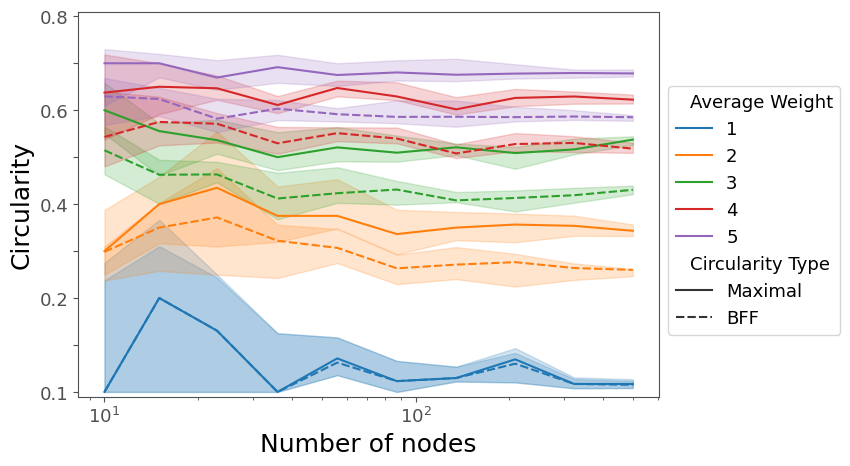

In [ ]:
plt.rcParams['font.size']=13

fig, ax = plt.subplots(1, 1, figsize = (7.5,5))

ax = sns.lineplot(ax = ax, data=exps_plot, x="num_nodes", y="circularity", estimator=np.median, errorbar= error,  
                  hue= 'Average Weight', style = 'Circularity Type', palette = "tab10")
leg = ax.get_legend()
leg.set( bbox_to_anchor = (1,0.83)) # loc="center right", fontsize = font_size_lable

font_size_lable = 18
ax.set_xlabel('Number of nodes', fontsize = font_size_lable)
ax.set_ylabel('Circularity', fontsize = font_size_lable)

ax.set_xscale('log')
ax.set(ylim=(-0.01, 0.81))

color_box = '#505050' #grey
ax.set_yticks([i/10 for i in range(9)], [0.1,'', 0.2, '', 0.4, '', 0.6, '', 0.8], color = color_box)

# ax.spines['right'].set_visible(False)
pos = ['right', 'top', 'left', 'bottom']
for p in pos:
    ax.spines[p].set_color(color_box)

font_size_ticks = 13
ax.tick_params(axis= 'both',  labelsize =  font_size_ticks, colors = color_box, which = 'both' )

# Saving figure
path_figure = os.path.join(dir_figures, "Figure3.pdf")
plt.savefig(path_figure, format='pdf',bbox_inches='tight')

plt.show()

matplotlib.rcParams.update(matplotlib.rcParamsDefault)

## Figure 4

In [40]:
# Load data
path_exps = os.path.join(path_data, "Figure4.csv")
exps = pd.read_csv(path_exps)

### Creating convenient dataframe for plot

In [42]:
# Duplicating data so we have one entry for Maximal and one for BFF

# Maximal
exps_plot1 = exps.drop(columns = ['BFF'])
exps_plot1.rename(columns = {'max' : 'circularity'}, inplace = True)
exps_plot1['circularity_type'] = 'max'
# BFF
exps_plot2 = exps.drop(columns = ['max'])
exps_plot2.rename(columns = {'BFF' : 'circularity'}, inplace = True)
exps_plot2['circularity_type'] = 'BFF'
exps_plot2
# Merge
exps_plot_raw = pd.concat([exps_plot1, exps_plot2], ignore_index=True)
exps_plot = exps_plot_raw.groupby(['num_nodes','average_weight', 'circularity_type'], as_index = False).mean()
type_map = {'max': 'Maximal', 'BFF' : 'BFF'}
exps_plot['circularity_type'] = exps_plot['circularity_type'].map(type_map)

# Add directedness 
exps_plot['directedness'] = 1-exps_plot['circularity']

# Sliccing of the start plot 
exps_plot_50 = exps_plot[exps_plot['average_weight']< 50]

### Ploting 

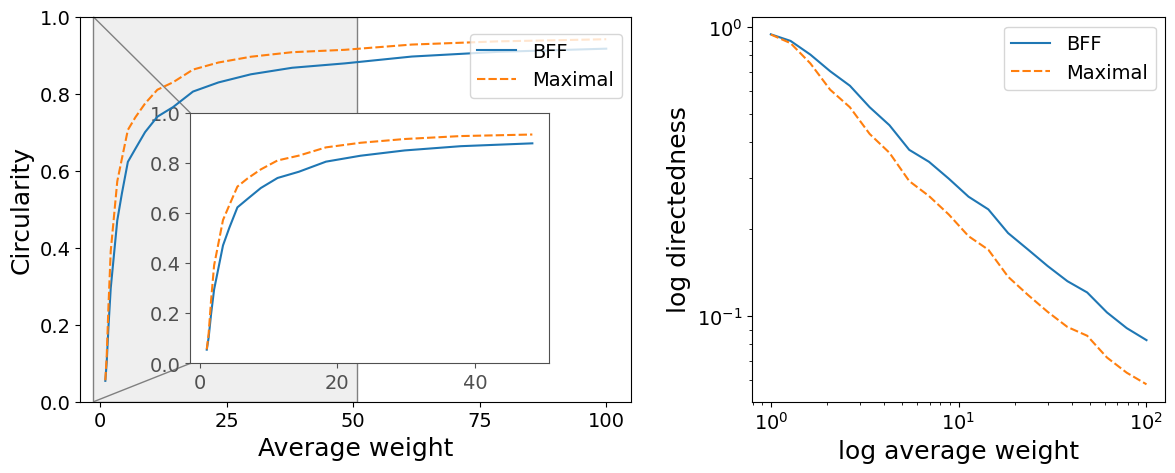

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5), gridspec_kw={'width_ratios': [4,-0.05, 3]})
ax[1].set_visible(False)

i = 0
sns.lineplot(ax = ax[i], data=exps_plot, x="average_weight", y="circularity", hue= 'circularity_type', style = 'circularity_type', palette = "tab10")

font_size_legend = 14
ax[i].legend( ncol=1, loc="upper right", bbox_to_anchor = (0,-0.02,1,1), fontsize = font_size_legend)# handles, labels, loc="upper right"

font_size_lable = 18
ax[i].set_xlabel('Average weight', fontsize = font_size_lable)
ax[i].set_ylabel('Circularity', fontsize = font_size_lable)
ax[i].set_ylim(0,1)

font_size_ticks = 14
color_box = 'black'
ax[i].tick_params(axis= 'both',  labelsize =  font_size_ticks, colors = color_box, which = 'both' )
pos = ['right', 'top', 'left', 'bottom']
for p in pos:
    ax[i].spines[p].set_color(color_box)
ax[i].locator_params(axis='x', nbins=5) 
ax[i].locator_params(axis='y', nbins=6) 

zoom = ax[i].inset_axes([0.2,0.1,0.65,0.65], zorder =0)

sns.lineplot(ax = zoom, data=exps_plot_50, x="average_weight", y="circularity", hue= 'circularity_type', style = 'circularity_type', palette = "tab10")
zoom.get_legend().set_visible(False)
zoom.set_xlabel('')
zoom.set_ylabel('')
zoom.set_ylim(0,1)
zoom.locator_params(axis='x', nbins=4)

color_box_zoom = '#505050' # grey
zoom.tick_params(axis= 'both',  labelsize =  font_size_ticks, colors = color_box_zoom, which = 'both' )
pos = ['right', 'top', 'left', 'bottom']
for p in pos:
    zoom.spines[p].set_color(color_box_zoom)


from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax[i], zoom, loc1=2, loc2=3, facecolor="#e0e0e080", edgecolor="grey",zorder =0) #zorder

i = 2
sns.lineplot(ax = ax[i], data=exps_plot, x="average_weight", y='directedness', hue= 'circularity_type', style = 'circularity_type', palette = "tab10")

ax[i].legend( ncol=1,  fontsize = font_size_legend)
ax[i].set_xscale('log')
ax[i].set_yscale('log')
ax[i].set_xlabel('log average weight',fontsize = font_size_lable)
ax[i].set_ylabel('log directedness', fontsize = font_size_lable)

ax[i].tick_params(axis= 'both',  labelsize =  font_size_ticks, colors = color_box, which = 'both' )
pos = ['right', 'top', 'left', 'bottom']
for p in pos:
    ax[i].spines[p].set_color(color_box)

# Saving figure
path_figure = os.path.join(dir_figures, "Figure4.pdf")
plt.savefig(path_figure, format='pdf',bbox_inches='tight')

plt.show()

## Figure 5

In [30]:
# Load data
path_exps = os.path.join(path_data, "Figure5.csv")
exps = pd.read_csv(path_exps)

# Shuffle the data so we can see all datasets
counts = exps.groupby('dataset').count()['file']
exps['fair_probability'] = 1 / counts[exps['dataset']].values
exps = exps.sample(frac=1, random_state = 100, weights = exps['fair_probability'])

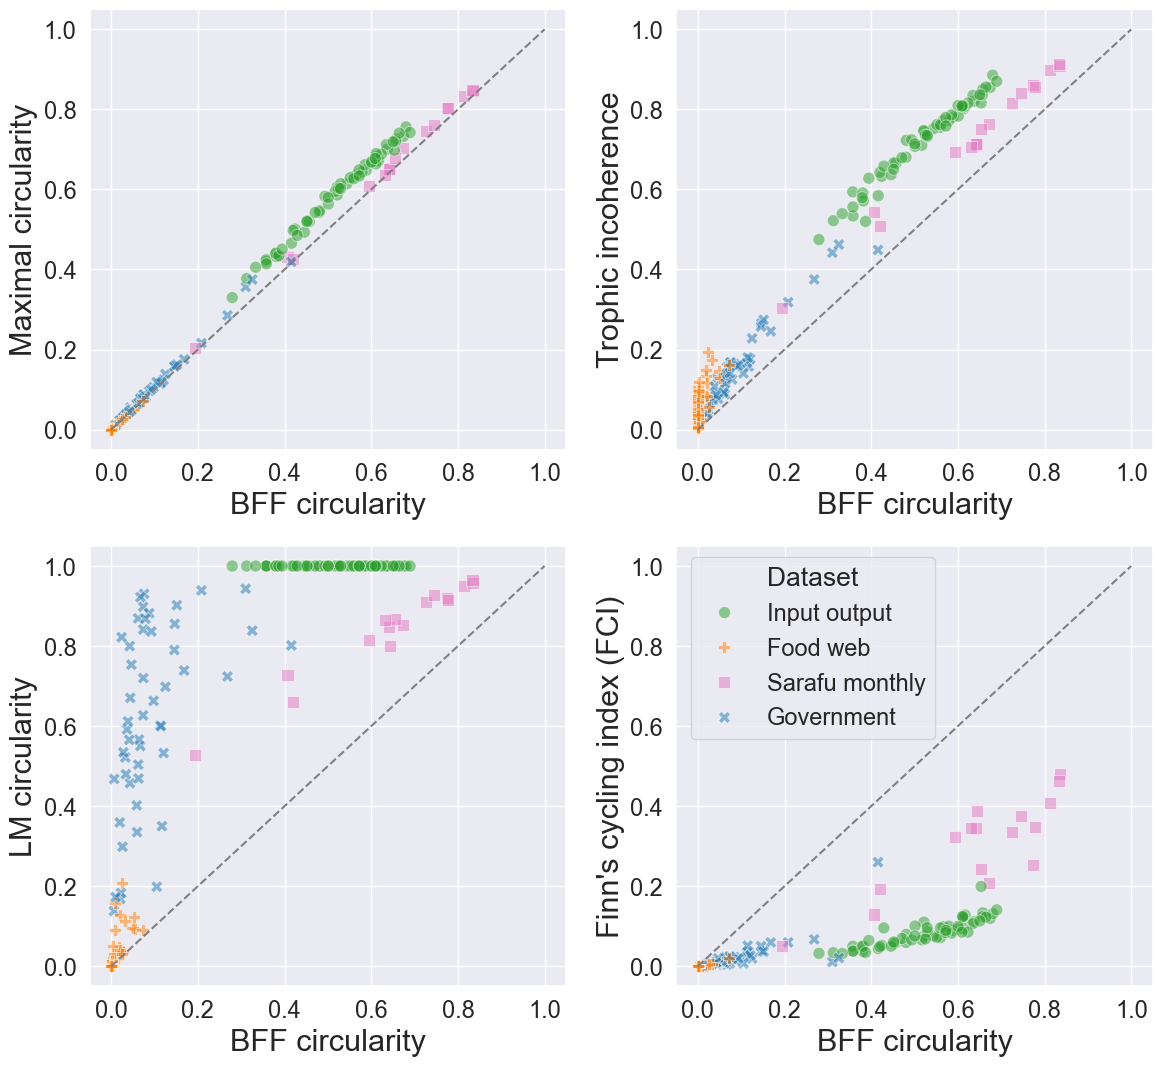

In [31]:
sns.set_theme(style="darkgrid")
measures = ['circ_max', 'incoherence', 'in_cycle_ratio', 'fci']
measures_mapping= {'incoherence':'Trophic incoherence', 'in_cycle_ratio':'LM circularity', 'circ_max':'Maximal circularity','fci':"Finn's cycling index (FCI)"}
palette = {'Food web':'tab:orange','Government':'tab:blue', 'Input output':'tab:green','Sarafu monthly':'tab:pink'}
markers = {"Food web": "P","Government" : "X",  "Input output": "o","Sarafu monthly":"s"}

font_size_lable = 22
font_size_ticks = 17
font_size_legend = 17
marker_size = 75



# Create 2×2 grid of scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.flatten()

for ax, measure in zip(axes, measures):
    sns.scatterplot(
        data=exps,
        x='circ_bff',
        y=measure,
        hue='dataset',
        style='dataset',
        palette=palette,
        alpha=0.5,
        markers=markers,
        ax=ax,
        s = marker_size
    )
    # y = x reference line
    ax.plot([0, 1], [0, 1], ls='--', c='gray')
    ax.set_xlim(-0.05, 1.05)
    # ax.set_ylim(-0.1, 1.01)
    ax.set_xlabel('BFF circularity', fontsize=font_size_lable)
    ax.set_ylabel(measures_mapping[measure], fontsize=font_size_lable)
    ax.tick_params(axis= 'both',  labelsize =  font_size_ticks )
    ax.get_legend().remove()

# Make legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc='center left',
    bbox_to_anchor=(0.58, 0.395),    # bbox_to_anchor=(1.0, 0.5),
    title='Dataset',
    fontsize=font_size_legend,
    title_fontsize=font_size_legend+2
)
fig.tight_layout(pad=1.6)
#fig.subplots_adjust(right=0.99)  # Adjust right margin to make space for legend

# Saving figure
path_figure = os.path.join(dir_figures, "Figure5.pdf")
plt.savefig(path_figure, format='pdf',bbox_inches='tight')